# Train XGBoost model (t+3 target)
Train an XGBoost classifier on `data/processed/xgboost_t3`, using `target_t+3` as the label and all columns except the target, `client_nr`, and `yearmonth` as features.

Hyperparameters are tuned with **Optuna**, maximizing PR-AUC on the validation split. The classification threshold is **not** tuned automatically: it is chosen manually below by inspecting the validation precision-recall curve against the business objective.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# walk up to the project root so this notebook works from its subfolder
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "models"))

import train_xgboost
from train_xgboost import (
    evaluate_all_splits,
    load_split,
    plot_precision_recall_curve,
    save_model,
    train_model,
)

HORIZON = "t3"
train_xgboost.set_horizon(HORIZON)
TARGET_COLUMN = train_xgboost.TARGET_COLUMN

c:\Users\SVisbee\Repos\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using dataset xgboost_t3 with target 'target_t+3'


## Tune hyperparameters and train

In [2]:
model, feature_columns, trials_df = train_model(n_trials=50)

Train observations: 18,803
Validation observations: 3,763
Number of features: 30

Class distribution in training data:
  Negative: 17,456
  Positive: 1,347
  scale_pos_weight: 12.96


Best trial: 39. Best value: 0.161207: 100%|██████████| 50/50 [00:17<00:00,  2.86it/s]



Best validation PR-AUC: 0.1612
Best hyperparameters:
  learning_rate: 0.05
  max_depth: 4
  min_child_weight: 5
  subsample: 1.0
  colsample_bytree: 0.85
  gamma: 1
  reg_alpha: 0.1
  reg_lambda: 1
  scale_pos_weight: 12.95916852264291


In [3]:
trials_df.sort_values("value", ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,state
42,42,0.161207,2026-08-31 00:20:07.805348,2026-08-31 00:20:08.265025,0 days 00:00:00.459677,0.85,1.0,0.05,4,5,0.1,1,1.0,COMPLETE
41,41,0.161207,2026-08-31 00:20:07.383765,2026-08-31 00:20:07.803345,0 days 00:00:00.419580,0.85,1.0,0.05,4,5,0.1,1,1.0,COMPLETE
48,48,0.161207,2026-08-31 00:20:10.513866,2026-08-31 00:20:11.031690,0 days 00:00:00.517824,0.85,1.0,0.05,4,5,0.1,1,1.0,COMPLETE
47,47,0.161207,2026-08-31 00:20:10.001949,2026-08-31 00:20:10.511785,0 days 00:00:00.509836,0.85,1.0,0.05,4,5,0.1,1,1.0,COMPLETE
45,45,0.161207,2026-08-31 00:20:09.173558,2026-08-31 00:20:09.657173,0 days 00:00:00.483615,0.85,1.0,0.05,4,5,0.1,1,1.0,COMPLETE
44,44,0.161207,2026-08-31 00:20:08.743143,2026-08-31 00:20:09.169989,0 days 00:00:00.426846,0.85,1.0,0.05,4,5,0.1,1,1.0,COMPLETE
39,39,0.161207,2026-08-31 00:20:06.490346,2026-08-31 00:20:06.975675,0 days 00:00:00.485329,0.85,1.0,0.05,4,5,0.1,1,1.0,COMPLETE
43,43,0.161207,2026-08-31 00:20:08.269026,2026-08-31 00:20:08.738403,0 days 00:00:00.469377,0.85,1.0,0.05,4,5,0.1,1,1.0,COMPLETE
49,49,0.154995,2026-08-31 00:20:11.034696,2026-08-31 00:20:11.545558,0 days 00:00:00.510862,0.85,1.0,0.03,4,5,0.1,1,1.0,COMPLETE
36,36,0.154907,2026-08-31 00:20:04.600595,2026-08-31 00:20:05.320566,0 days 00:00:00.719971,0.85,1.0,0.05,4,50,0.1,1,1.0,COMPLETE


## Select the classification threshold
Inspect the precision-recall curve on the **validation** split (train would be optimistic, test must stay untouched) and pick the threshold matching the business objective.

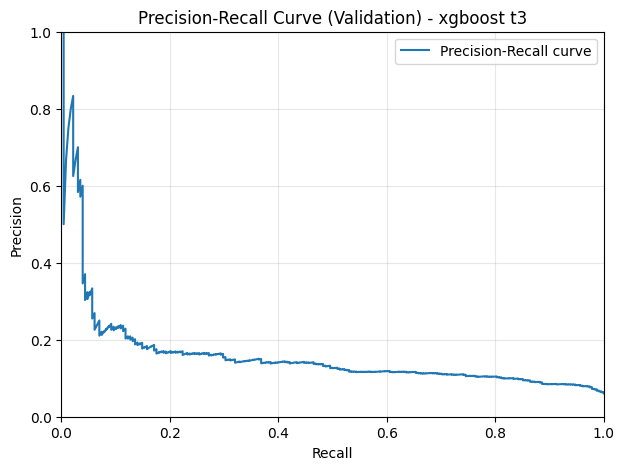

In [4]:
val_df = load_split("val")

threshold_table = plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    title=f"Precision-Recall Curve (Validation) - xgboost {HORIZON}",
)

In [6]:
# inspect candidate operating points to pick a threshold
threshold_table = threshold_table.sort_values(by="recall", ascending=False)
threshold_table[threshold_table["precision"] >= 0.4].head(20)

,threshold,precision,recall
3628,0.776756,0.428571,0.039474
3627,0.776256,0.409091,0.039474
3634,0.778685,0.600000,0.039474
3631,0.777859,0.500000,0.039474
3632,0.778240,0.529412,0.039474
3633,0.778336,0.562500,0.039474
3629,0.777426,0.450000,0.039474
3630,0.777707,0.473684,0.039474
3635,0.778731,0.571429,0.035088
3636,0.779570,0.615385,0.035088


### Chosen threshold
Set `SELECTED_THRESHOLD` below based on the curve and table above.

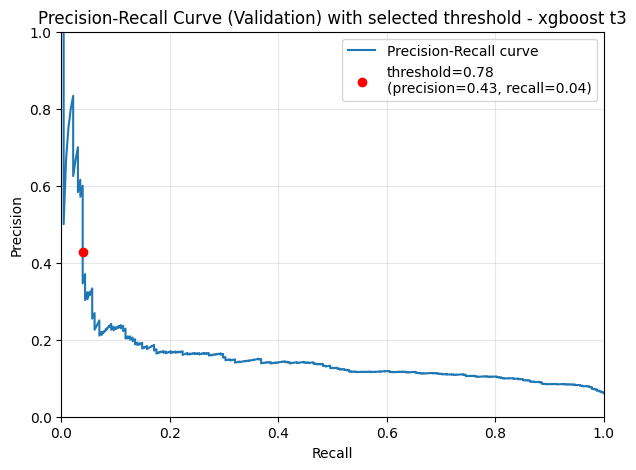

In [7]:
SELECTED_THRESHOLD = 0.776756

plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    threshold=SELECTED_THRESHOLD,
    title=f"Precision-Recall Curve (Validation) with selected threshold - xgboost {HORIZON}",
);

## Final evaluation

In [8]:
evaluate_all_splits(model, feature_columns, threshold=SELECTED_THRESHOLD)

,pr_auc,precision,recall,f1,precision_at_k (k=90),recall_at_k (k=90)
train,0.203418,0.473684,0.006682,0.013177,0.411111,0.027468
val,0.161207,0.450000,0.039474,0.072581,0.233333,0.092105
test,0.159152,0.230769,0.021978,0.040134,0.266667,0.087912


## Save the model
Persist the fitted model together with its feature list and chosen threshold, so it can be reloaded for comparison and inference.

In [9]:
save_model(model, feature_columns, threshold=SELECTED_THRESHOLD)

Saved model to C:\Users\SVisbee\Repos\Credit_prediction_case\models\artifacts\xgboost_t3.joblib


WindowsPath('C:/Users/SVisbee/Repos/Credit_prediction_case/models/artifacts/xgboost_t3.joblib')